In [1]:
import pandas as pd

In [2]:
import sys
from pathlib import Path

In [3]:
sys.path.append(str(Path().resolve().parent))

In [4]:
from src.data.load_data import load_csv_data

In [5]:
df=load_csv_data("../data/raw/train.csv")


Data loaded successfully from ../data/raw/train.csv
Data shape: (1460, 81)


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
missing_value_percentage=df.isnull().sum()/len(df)*100
missing_value_percentage.sort_values(ascending=False)

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

In [16]:
high_missing_value_columns=missing_value_percentage[missing_value_percentage>50]
low_missing_value_columns=missing_value_percentage[(missing_value_percentage>0) & (missing_value_percentage<=50)]
print("Columns with high missing values (>50%):", high_missing_value_columns.index.tolist())
print("Columns with low missing values (0-50%):", low_missing_value_columns.index.tolist()) 

Columns with high missing values (>50%): ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
Columns with low missing values (0-50%): ['LotFrontage', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']


In [24]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

categorical_cols

C:\Users\Shrajan\AppData\Local\Temp\ipykernel_14008\3525351675.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [25]:
categorical_missing = df[
    categorical_cols
].isnull().sum()

categorical_missing = categorical_missing[
    categorical_missing > 0
]

categorical_missing.sort_values(
    ascending=False
)

MiscFeature     1406
Alley           1369
GarageCond        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
Electrical         1
dtype: int64

In [26]:
categorical_fill_none = [
    "PoolQC",
    "Fence",
    'MasVnrType',
    "FireplaceQu",
    "GarageType"
]

for col in categorical_fill_none:
    df[col] = df[col].fillna("None")

In [27]:
number_cols = df.select_dtypes(
    include=["number"]
).columns

number_cols = df.select_dtypes(
    include=["number"]
).columns

In [28]:
number_missing = df[
    number_cols
].isnull().sum()

number_missing = number_missing[
    number_missing > 0
]

number_missing.sort_values(
    ascending=False
)

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64

In [29]:
df["LotFrontage"] = df["LotFrontage"].fillna(
    df["LotFrontage"].median()
)

In [32]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)

MiscFeature     1406
Alley           1369
GarageYrBlt       81
GarageQual        81
GarageCond        81
GarageFinish      81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
MSSubClass         0
LotFrontage        0
MSZoning           0
HouseStyle         0
BldgType           0
Condition2         0
dtype: int64

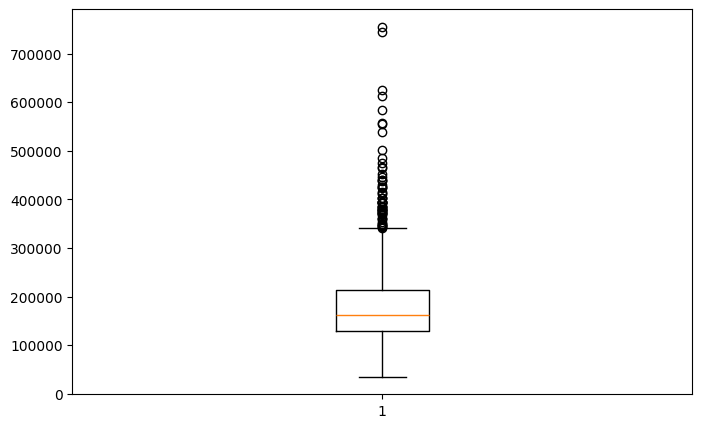

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df["SalePrice"])
plt.show()

In [36]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)

MiscFeature     1406
Alley           1369
GarageYrBlt       81
GarageQual        81
GarageCond        81
GarageFinish      81
BsmtExposure      38
BsmtFinType2      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
MSSubClass         0
LotFrontage        0
MSZoning           0
HouseStyle         0
BldgType           0
Condition2         0
dtype: int64

In [37]:
from src.data.preprocess import (
    fill_categorical_none,
    fill_numerical_median,
    fill_numerical_mean
)

In [38]:
categorical_cols

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [41]:
number_cols
number_missing

LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64

In [43]:
categorical_missing


Alley           1369
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
GarageFinish      81
GarageQual        81
GarageCond        81
MiscFeature     1406
dtype: int64

In [44]:
categorical_fill_none_cols = [
    "PoolQC",
    "Fence",
    "GarageFinish",
    "GarageType"
]

numerical_median_cols = [
    "LotFrontage",
    "MasVnrArea"
]

df = fill_categorical_none(
    df,
    categorical_fill_none_cols
)

df = fill_numerical_median(
    df,
    numerical_median_cols
)

In [45]:
df.isnull().sum().sort_values(
    ascending=False
).head(20)

MiscFeature     1406
Alley           1369
GarageYrBlt       81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
Electrical         1
Id                 0
MSSubClass         0
LotArea            0
Street             0
LotFrontage        0
MSZoning           0
HouseStyle         0
BldgType           0
Condition2         0
dtype: int64

In [46]:
processed_data_path = "../data/processed/train_cleaned.csv"

df.to_csv(
    processed_data_path,
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
